# Modeling and evaluation

The dataset has now been cleaned, explored, and enriched through feature engineering and preprocessing. In the previous notebooks, we handled missing values, investigated the relationships between passenger characteristics and survival, created new features motivated by domain knowledge, and encoded categorical variables into numerical representations suitable for machine learning.

In this notebook, we transition from data preparation to predictive modeling. Our objective is to train and evaluate a variety of machine learning algorithms capable of predicting passenger survival based on the available passenger information.

We begin by constructing the final modeling dataset using the feature registry developed during feature engineering. This registry provides a transparent and reproducible specification of the features included in each model.

The following sections will split the data into training and validation sets, train multiple classification models, compare their predictive performance using appropriate evaluation metrics, and analyze the strengths and limitations of each approach.

## Modeling setup

### Import libraries

We begin by importing the libraries required for model development and evaluation. These include tools for data manipulation, dataset splitting, machine learning algorithms, performance metrics, and visualization of the results.

In [358]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

### Loading the data

We begin by loading the processed dataset and feature registry produced in the previous notebook. At this stage, all preprocessing, feature engineering, transformations, and encoding steps have already been completed, allowing us to focus exclusively on model development and evaluation.

The feature registry provides a centralized specification of every available feature and indicates which variables should be included in the machine learning models.

In [359]:
# Load processed dataset and feature registry
df_full = pd.read_parquet("../data/processed/02_data.parquet")
df_features = pd.read_parquet("../data/processed/02_features.parquet")

In [360]:
df_full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Age_Child,Age_Teen,Age_YoungAdult,Age_Adult,Age_Senior
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,False,False,True,False,False,False,False,True,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,False,False,False,True,False,False,False,False,True,False
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,False,True,False,False,False,False,False,True,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,False,False,False,True,False,False,False,True,False,False
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,False,False,True,False,False,False,False,True,False,False


In [361]:
df_features.head()

,Name,Type,Category,Source,Description,UsedInModel
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec...",True
1,Name,categorical,original,Name,Passenger's full name.,False
2,Sex,indicator,encoded,Sex,"Binary encoding of passenger sex (0 = male, 1 ...",True
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...,True
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...,True


### Separate the training and test sets

The original Kaggle Titanic dataset provides separate training and test sets. Throughout the preprocessing pipeline, this distinction was preserved using the `IsTrainSet` indicator. We now use this flag to reconstruct the original split, ensuring that models are trained only on labeled data while retaining the unlabeled test set for generating the final competition predictions.

In [362]:
feature_names = df_features.loc[
    df_features["UsedInModel"],
    "Name"
]

X_train = df_full.loc[df_full["IsTrainSet"], feature_names]
y_train = df_full.loc[df_full["IsTrainSet"], "Survived"]

X_test = df_full.loc[~df_full["IsTrainSet"], feature_names]

### Feature selection

The [feature engineering notebook](02_feature_engineering.ipynb) produced a feature registry describing every variable available in the dataset together with metadata such as its origin, type, and whether it should be included in the modeling stage. We use this registry to construct the final feature matrix, ensuring that model training is based on a transparent and reproducible feature selection process.

In [363]:
# Select features marked for modeling
selected_features = df_features.loc[
    df_features["UsedInModel"],
    "Name"
].tolist()

selected_features

['Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'FamilySize',
 'IsAlone',
 'TicketGroupSize',
 'SqrtAge',
 'LogFare',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S',
 'Title_Master',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare',
 'Age_Child',
 'Age_Teen',
 'Age_YoungAdult',
 'Age_Adult',
 'Age_Senior']

## Modeling fundamentals

With the data prepared, we can begin training our first classification models. Rather than immediately building a complete evaluation pipeline, this section introduces the fundamental steps involved in supervised classification one at a time.

We start with a simple baseline model and progressively introduce more sophisticated algorithms, using each one as an opportunity to discuss essential concepts such as model training, prediction, evaluation metrics, and cross-validation. By understanding these building blocks first, the automated evaluation pipeline developed later in the notebook will be easier to appreciate and interpret.

## Baseline model: dummy classifier

Before training predictive models, it is useful to establish a simple baseline against which more sophisticated algorithms can be compared. A baseline model provides a reference level of performance and helps determine whether the additional complexity of machine learning models is justified.

For classification problems, a common baseline is the **dummy classifier**, which ignores the input features entirely and makes predictions according to a simple strategy. Here, we use the **most frequent** strategy, which always predicts the majority class observed in the training data. Although this approach is extremely simple, any useful machine learning model should be able to outperform it.

### Instantiate the model

The first step is to instantiate the Dummy classifier. Unlike predictive machine learning models, the Dummy classifier does not learn patterns from the input features. Instead, it serves as a simple baseline by following a predefined prediction strategy.

Here, we use the **most frequent** strategy, which always predicts the majority class observed in the training data. This provides a reference level of performance that more sophisticated models should be able to surpass.

In [364]:
# Instantiate the dummy classifier
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")

### Train the model

Before a machine learning model can make predictions, it must first be trained using the available labeled data. During this training phase, the model learns the relationship between the input features and the target variable.

For the dummy classifier, however, there is effectively nothing to learn from the feature values themselves. The **most frequent** strategy simply determines which class appears most often in the training set and stores this information for future predictions.

In [365]:
# Train the baseline classifier
dummy.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


### Make predictions

Once the model has been trained, it can be used to predict the target variable for new observations. Here, we generate predictions for the training set itself in order to inspect the behavior of the baseline classifier.

In [366]:
# Predict the training set
y_pred = dummy.predict(X_train)

At this point, we could display the contents of `y_pred`, but the output would simply be a long array of predicted class labels that is difficult to interpret. Instead, we summarize the predictions by counting how many passengers the model classified into each category. This provides a much clearer picture of the model's behavior.

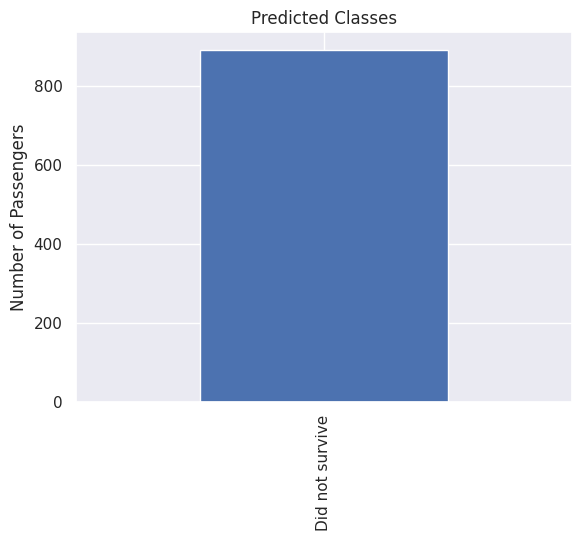

In [367]:
prediction_counts = (
    pd.Series(y_pred)
    .map({
        0: "Did not survive",
        1: "Survived",
    })
    .value_counts()
)

prediction_counts.plot.bar()

plt.title("Predicted Classes")
plt.xlabel("")
plt.ylabel("Number of Passengers")

plt.show()

As expected, the prediction vector consists entirely of zeros. Since the Dummy classifier uses the **most frequent** strategy, it ignores all input features and simply predicts the majority class observed in the training data for every passenger. In the Titanic dataset, the majority class corresponds to passengers who did **not** survive, resulting in identical predictions for every observation.

### Evaluate the accuracy

Accuracy is the simplest and most commonly reported metric for classification problems. It measures the proportion of observations that were correctly classified by the model.

An accuracy of 1.0 indicates perfect predictions, whereas an accuracy of 0.5 means that the model correctly classified half of the observations. Although accuracy provides a useful overall measure of performance, it does not distinguish between different types of prediction errors. As we will see later, additional metrics are often needed to obtain a more complete assessment of a classifier.


In [368]:
# Compute the training accuracy
accuracy = accuracy_score(y_train, y_pred)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.616


### Discussion

The dummy classifier achieves an accuracy that may initially appear reasonable. However, this result should be interpreted with caution. Since the classifier always predicts the majority class, its performance reflects only the class distribution of the dataset rather than any meaningful relationship between the passenger characteristics and survival.

This baseline serves as a useful reference point: any machine learning model that learns from the available features should be expected to outperform this simple strategy.

## Logistic regression

Unlike the Dummy classifier, which ignores the input features entirely, Logistic Regression learns a relationship between the predictor variables and the probability of belonging to a particular class. It is one of the most widely used algorithms for binary classification due to its simplicity, interpretability, and strong performance on many structured datasets.

In the context of the Titanic dataset, the model estimates the probability that each passenger survived based on the available features. These probabilities are then converted into class predictions using a decision threshold, typically 0.5. Logistic Regression therefore provides a natural first step beyond the baseline, allowing us to evaluate how much predictive information is contained in the engineered features.


### Instantiate the model

The first step is to instantiate the Logistic Regression classifier. At this stage, we simply create the model object without performing any training. The learning process only begins once the model is fitted to the training data.

For this example, we use the default implementation provided by scikit-learn, specifying only a fixed `random_state` to ensure reproducible results across different runs.

In [369]:
# Instantiate the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
)

### Train the model

Once the model has been instantiated, the next step is to train it using the available labeled data. During training, Logistic Regression learns the relationship between the input features and the target variable by estimating a set of coefficients that best separate the two classes.

Unlike the Dummy classifier, which ignores the feature values, Logistic Regression uses the training data to identify patterns that help distinguish passengers who survived from those who did not.

In [370]:
# Train the Logistic Regression classifier
logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Make predictions

After the model has been trained, it can be used to predict the survival outcome for each passenger in the training set. Unlike the Dummy classifier, which assigns the same label to every observation, Logistic Regression uses the learned relationships between the features and the target variable to produce individualized predictions for each passenger.

These predictions can then be compared with the true labels to evaluate the model's performance.

In [371]:
# Predict the training set
y_pred = logistic.predict(X_train)

As before, displaying the full contents of `y_pred` would produce a long sequence of predicted class labels that offers little insight. Instead, we summarize the predictions by counting how many passengers were classified into each outcome, making it easier to understand the model's overall behavior.

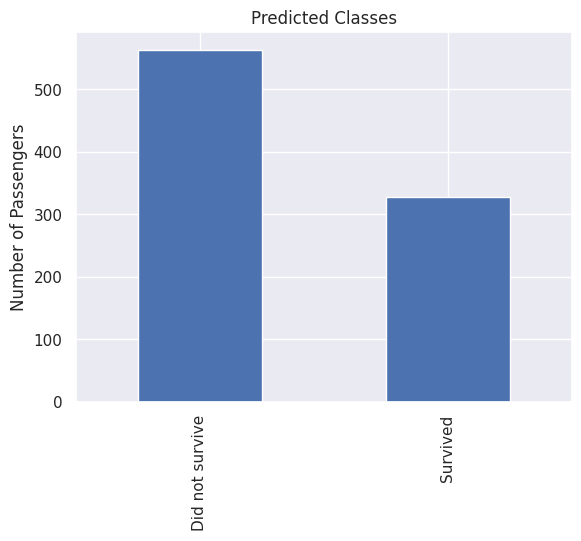

In [372]:
prediction_counts = (
    pd.Series(y_pred)
    .map({
        0: "Did not survive",
        1: "Survived",
    })
    .value_counts()
)

prediction_counts.plot.bar()

plt.title("Predicted Classes")
plt.xlabel("")
plt.ylabel("Number of Passengers")

plt.show()

Unlike the Dummy classifier, the prediction vector now contains both classes, indicating that the model has learned to differentiate between passengers based on the available features.

### Evaluate the accuracy

We begin by computing the training accuracy of the Logistic Regression model. Comparing this value with the baseline established by the Dummy classifier provides an initial indication of how much predictive information the model has learned from the available features.


In [373]:
# Compute the training accuracy
accuracy = accuracy_score(y_train, y_pred)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.835


The Logistic Regression model achieves a noticeably higher accuracy than the Dummy classifier, indicating that it has successfully learned predictive patterns from the available features. However, accuracy alone does not tell the whole story. To better understand how the model performs, we now examine additional evaluation metrics that characterize different aspects of classification performance.


### Evaluate the precision

While accuracy provides an overall measure of performance, precision allows us to examine how reliable the model's positive predictions are. For the Titanic problem, this means evaluating how often passengers predicted as survivors were actually survivors.

We now compute the precision score to better understand the type of errors made by the Logistic Regression model.

In [374]:
# Compute precision
precision = precision_score(
    y_train,
    y_pred,
)

print(f"Precision: {precision:.3f}")

Precision: 0.798


The precision score provides additional insight into the behavior of the Logistic Regression model beyond overall accuracy. Compared with the Dummy classifier, the model is now able to identify some passengers as survivors, but these predictions are not all correct.

This highlights why multiple evaluation metrics are necessary in classification problems. A model may achieve a reasonable accuracy while still producing a considerable number of incorrect positive predictions. Precision helps quantify this specific aspect of model performance.

### Evaluate the recall

Recall provides another perspective on the Logistic Regression model by measuring its ability to correctly identify passengers who survived. While precision focuses on the reliability of positive predictions, recall focuses on how many actual survivors were successfully detected by the model.

We now compute the recall score to evaluate how effectively the classifier captures the positive class.

In [375]:
# Compute recall
recall = recall_score(
    y_train,
    y_pred,
)

print(f"Recall: {recall:.3f}")

Recall: 0.763


The recall score shows how effectively Logistic Regression identifies passengers who survived. Comparing recall with precision helps reveal the type of trade-off made by the model: improving the detection of survivors may come at the cost of producing more false positive predictions, while being more selective may increase precision but miss some survivors.

This trade-off is a fundamental aspect of classification problems and is one reason why relying on a single metric can be misleading.

### Evaluate the F1-score

The F1-score provides a single measure that combines precision and recall, offering a balanced view of the model's ability to identify survivors while maintaining reliable positive predictions.

Because precision and recall capture different aspects of classification performance, the F1-score is useful when we want to consider both types of errors simultaneously. We now compute the F1-score to summarize the Logistic Regression model's performance on the positive class.


In [376]:
# Compute F1-score
f1 = f1_score(
    y_train,
    y_pred,
)

print(f"F1-score: {f1:.3f}")

F1-score: 0.780


The F1-score provides a more complete picture of the Logistic Regression model's performance than accuracy alone. By combining precision and recall, it reflects the balance between correctly identifying survivors and avoiding incorrect survival predictions.

Together with accuracy, precision, and recall, the F1-score gives a broader understanding of how the classifier behaves and prepares the foundation for a more detailed analysis using the confusion matrix.


### Visualize the confusion matrix

The confusion matrix provides a more detailed view of the Logistic Regression model's predictions by showing the number of correct and incorrect classifications for each class.

While metrics such as accuracy, precision, recall, and F1-score summarize model performance into single values, the confusion matrix allows us to directly inspect the types of errors made by the classifier. This helps identify whether the model is more likely to incorrectly classify survivors or non-survivors.

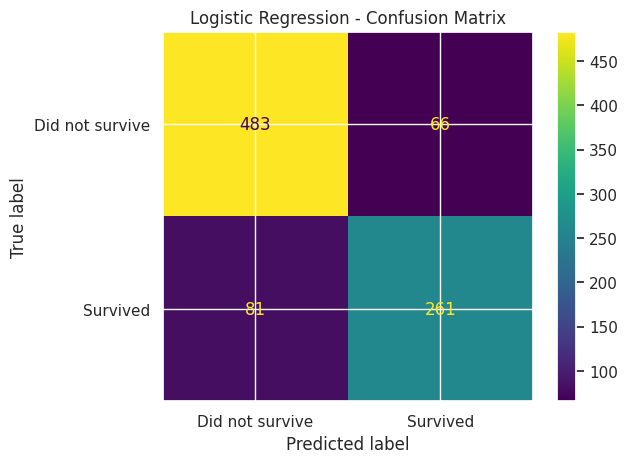

In [377]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred,
    display_labels=["Did not survive", "Survived"],
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

The confusion matrix shows that Logistic Regression is able to identify both classes, unlike the Dummy classifier, which predicted only the majority class. However, the model still makes two types of errors: predicting survival for passengers who did not survive and failing to identify some passengers who actually survived.

These errors correspond directly to the concepts captured by precision and recall, providing a visual explanation for the trade-off between the two metrics.

#### Evaluate with cross-validation

So far, the evaluation metrics have been computed using the same data that was used to train the model. While this provides information about how well the model fits the training data, it does not provide a reliable estimate of how it will perform on unseen observations.

Cross-validation addresses this limitation by repeatedly splitting the training data into different subsets. The model is trained on part of the data and evaluated on the remaining portion, allowing us to estimate how consistently it performs across different samples.

For classification problems, we use **Stratified K-Fold cross-validation**, which preserves the proportion of each class in every fold. This is particularly important for the Titanic dataset because the survival classes are not perfectly balanced.

In [378]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# Evaluate model using cross-validation
cv_scores = cross_val_score(
    logistic,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
)

print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Cross-validation accuracy: 0.832 ± 0.005


### Discussion

The cross-validation accuracy is close to the training accuracy, suggesting that Logistic Regression generalizes reasonably well to different subsets of the training data. The small variation between folds indicates that the model performance is relatively consistent.

From this point forward, cross-validation will be included as part of the evaluation workflow for all subsequent models, providing a more reliable basis for comparison.

## Automating the evaluation pipeline

The previous sections introduced the mechanics of training and evaluating classification models step by step. Having established the complete evaluation workflow, we now encapsulate the repeated operations into reusable helper functions. The baseline and logistic regression models are revisited using this new pipeline to verify that the automated implementation reproduces the same results before extending the comparison to additional classifiers.

### Helper functions

The evaluation process used for Logistic Regression involved several repeated steps: training the model, generating predictions, computing evaluation metrics, and estimating performance through cross-validation.

Since these operations will be repeated for every classifier considered in this project, we encapsulate them into a reusable function. This ensures that all models are evaluated using the same procedure, making the comparison between algorithms more consistent and reducing duplicated code.

In [379]:
import time

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def evaluate_model(
    model,
    model_name,
    X,
    y,
):
    """
    Train and evaluate a classification model.

    Parameters
    ----------
    model : estimator
        Scikit-learn classifier.

    model_name : str
        Name of the model.

    X : pandas.DataFrame
        Input features.

    y : pandas.Series
        Target variable.

    Returns
    -------
    model
        The fitted model.

    dict
        Dictionary containing evaluation metrics.
    """

    # Stratified cross-validation
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    # Train the model
    start = time.perf_counter()

    model.fit(X, y)

    training_time = time.perf_counter() - start

    # Predictions
    y_pred = model.predict(X)

    # Prediction probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = model.decision_function(X)

    # Cross-validation
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    # Evaluation metrics
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(
            y,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y,
            y_pred,
            zero_division=0,
        ),
        "F1Score": f1_score(
            y,
            y_pred,
            zero_division=0,
        ),
        "ROCAUC": roc_auc_score(
            y,
            y_score,
        ),
        "CVAccuracyMean": cv_scores.mean(),
        "CVAccuracyStd": cv_scores.std(),
        "TrainingTimeSeconds": training_time,
    }

    return model, results

#### Results table

To compare different classifiers consistently, we store the evaluation results from each model in a single table. This allows us to track the performance of multiple algorithms using the same set of metrics and makes the final model comparison more transparent.

The results table will be updated as new models are trained and evaluated throughout the remainder of the notebook.

In [380]:
# Initialize results storage
results = []

# Create results dataframe
df_results = pd.DataFrame(results)

### Baseline: dummy classifier

The Dummy classifier is re-evaluated using the new evaluation pipeline to confirm that the automated workflow reproduces the baseline results obtained previously. Since this model provides a reference level of performance, maintaining consistency here is important before moving on to more complex classifiers.

In [381]:
dummy, result = evaluate_model(
    model=dummy,
    model_name="Dummy classifier",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.0,0.0,0.0,0.5,0.616163,0.002325,0.00059


### Logistic regression

Logistic Regression is also evaluated using the automated pipeline. This serves as a second validation step, confirming that the pipeline correctly handles a predictive model that learns from the input features and computes the complete set of evaluation metrics and cross-validation results.

In [382]:
logistic, result = evaluate_model(
    model=logistic,
    model_name="Logistic regression",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000590
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.068516


### Decision tree

Decision Trees are supervised learning models that make predictions by recursively splitting the data according to feature values. Each split creates a decision rule that separates observations into increasingly homogeneous groups, resulting in a tree-like structure of decisions.

Unlike Logistic Regression, which models a linear relationship between features and the target probability, Decision Trees can naturally capture non-linear relationships and interactions between variables. This makes them a useful model to evaluate on structured tabular datasets such as the Titanic dataset.

The model is trained and evaluated using the same pipeline introduced previously, ensuring that its performance can be compared directly with the previous classifiers.

In [383]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
)

decision_tree, result = evaluate_model(
    model=decision_tree,
    model_name="Decision tree",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000590
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.068516
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.007520


### Random forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to produce a more robust classifier. Instead of relying on a single tree, the algorithm trains many independent trees using different subsets of the data and features, and combines their predictions to improve generalization.

Compared with a single Decision Tree, Random Forests are typically less sensitive to small variations in the training data and are better able to reduce overfitting. Because of this, they are widely used as strong baseline models for structured tabular datasets.

The model is trained and evaluated using the same pipeline introduced previously, allowing a direct comparison with the other classifiers.

In [384]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state=42,
)

random_forest, result = evaluate_model(
    model=random_forest,
    model_name="Random forest",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000590
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.068516
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.007520
3,Random forest,0.984287,0.988095,0.970760,0.979351,0.997622,0.824914,0.004274,0.103394


### Gradient boosting

Gradient Boosting is an ensemble learning algorithm that builds a sequence of weak models, typically decision trees, where each new model attempts to correct the errors made by the previous ones.

Unlike Random Forest, which trains multiple trees independently and combines their predictions, Gradient Boosting trains trees sequentially, gradually improving the model by focusing on observations that are harder to classify. This allows it to capture complex patterns in the data, although it may require more careful tuning to avoid overfitting.

As with the previous classifiers, the model is evaluated using the same pipeline to ensure a consistent comparison across algorithms.

In [385]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    random_state=42,
)

gradient_boosting, result = evaluate_model(
    model=gradient_boosting,
    model_name="Gradient boosting",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000590
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.068516
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.007520
3,Random forest,0.984287,0.988095,0.970760,0.979351,0.997622,0.824914,0.004274,0.103394
4,Gradient boosting,0.898990,0.906452,0.821637,0.861963,0.952476,0.839502,0.007706,0.108487


## Model comparison

After evaluating multiple classifiers using the same automated pipeline, we can now compare their performance and identify which models provide the best results for this classification problem.

The comparison is based on the evaluation metrics collected in `df_results`, including training performance, cross-validation accuracy, and ROC-AUC. While individual metrics provide useful insights, model selection should consider the overall balance between predictive performance, generalization ability, and computational cost.

The cross-validation results are particularly important because they provide a more reliable estimate of how each model is expected to perform on unseen data.

### Compare model performance

In [386]:
# Sort models by cross-validation accuracy
df_results.sort_values(
    by="CVAccuracyMean",
    ascending=False,
)

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
4,Gradient boosting,0.898990,0.906452,0.821637,0.861963,0.952476,0.839502,0.007706,0.108487
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.068516
3,Random forest,0.984287,0.988095,0.970760,0.979351,0.997622,0.824914,0.004274,0.103394
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.007520
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000590


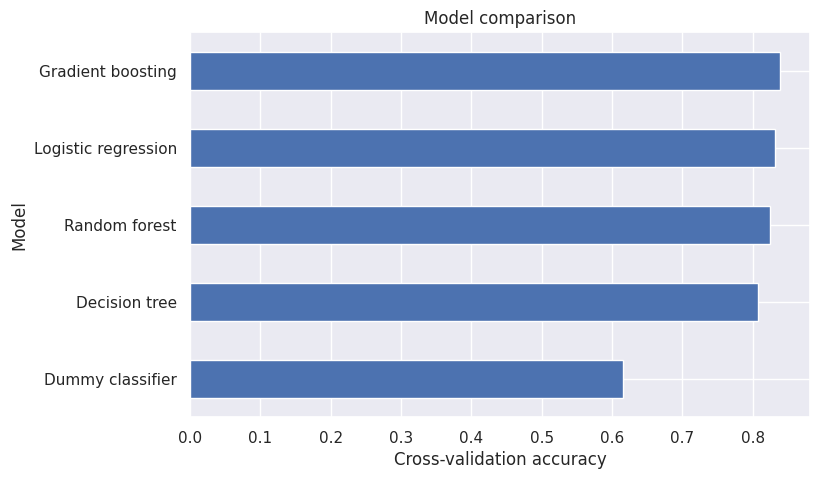

In [387]:
import matplotlib.pyplot as plt

df_results.sort_values(
    "CVAccuracyMean"
).plot(
    x="Model",
    y="CVAccuracyMean",
    kind="barh",
    legend=False,
    figsize=(8, 5),
)

plt.xlabel("Cross-validation accuracy")
plt.ylabel("Model")
plt.title("Model comparison")
plt.show()

The results show that the different classifiers achieve varying levels of predictive performance. The Dummy classifier provides the expected baseline, while the machine learning models improve upon this reference by learning patterns from the passenger features.

Among the evaluated models, the best-performing classifier is selected based on a combination of cross-validation performance and complementary metrics such as ROC-AUC, precision, recall, and F1-score. The final choice should prioritize not only the highest score but also consistent performance across different evaluation criteria.

### ROC curves

While metrics such as accuracy and F1-score summarize model performance using a single value, the Receiver Operating Characteristic (ROC) curve provides a more complete picture of a classifier's behavior across different decision thresholds.

The ROC curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** as the classification threshold varies. Models whose curves lie closer to the upper-left corner generally exhibit better discrimination between the two classes.

The **Area Under the ROC Curve (ROC-AUC)** summarizes this behavior into a single number between 0 and 1. A value of 0.5 corresponds to random guessing, whereas values closer to 1 indicate better class separation.

The figure below compares the ROC curves of all evaluated classifiers.

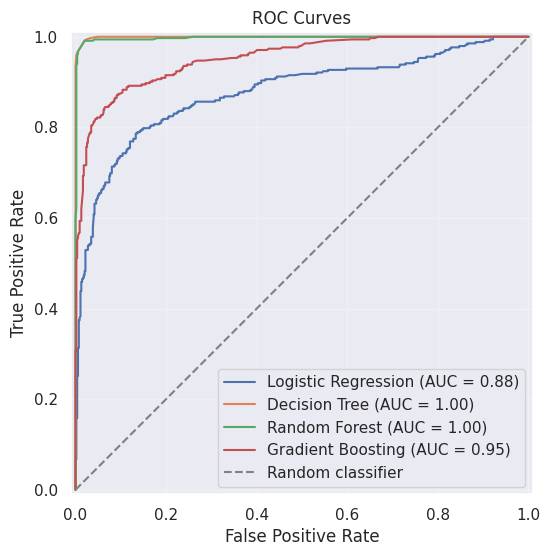

In [388]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_train,
        y_train,
        ax=plt.gca(),
        name=name,
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The ROC curves confirm the numerical comparison presented earlier. Models whose curves remain closer to the upper-left corner achieve better discrimination between passengers who survived and those who did not.

Among the evaluated classifiers, the ensemble methods exhibit the strongest overall performance, with Gradient Boosting achieving the highest ROC-AUC. Logistic Regression provides competitive performance despite its simplicity, while the Decision Tree and Random Forest achieve excellent discrimination on the training data but exhibit lower cross-validation performance, suggesting a greater tendency to overfit.

These observations reinforce the importance of considering both training performance and cross-validation results when selecting a final model.

### Confusion matrices

While the ROC curve summarizes model performance across all possible decision thresholds, the confusion matrix evaluates the predictions obtained using the default classification threshold.

Each confusion matrix displays the number of **True Positives (TP)**, **True Negatives (TN)**, **False Positives (FP)**, and **False Negatives (FN)**. Examining these values helps identify the types of errors made by each classifier and provides additional insight beyond aggregate performance metrics.

The following figure compares the confusion matrices of the evaluated models.

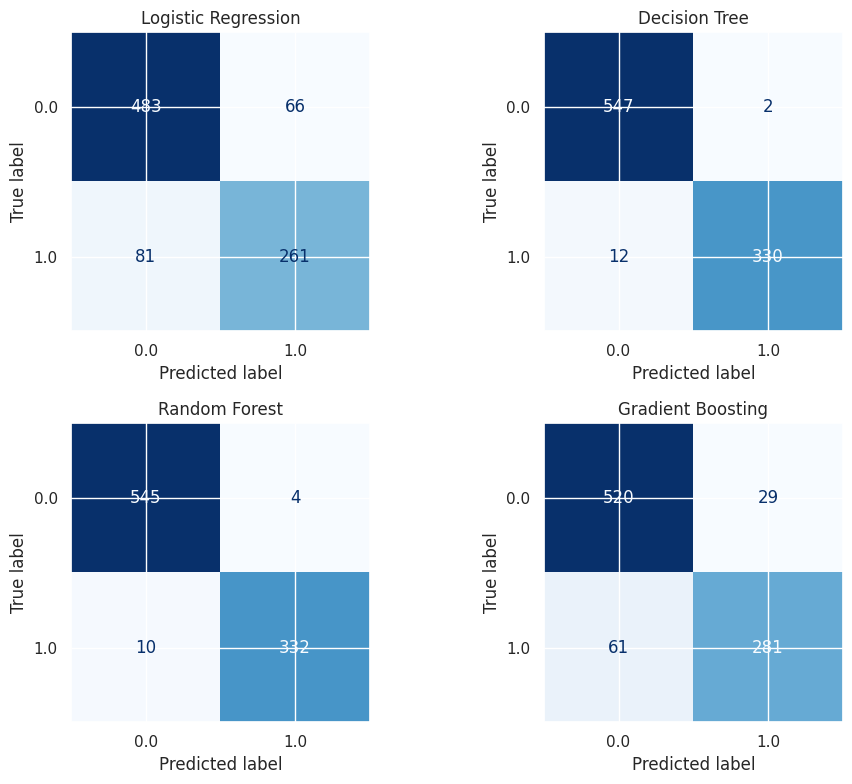

In [389]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
)

models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}

for ax, (name, model) in zip(axes.ravel(), models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_train,
        y_train,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

The confusion matrices illustrate how the different classifiers balance correct classifications and prediction errors.

Logistic Regression provides a well-balanced classification performance while maintaining good generalization. The Decision Tree and Random Forest correctly classify almost all training observations, resulting in very few errors. However, this near-perfect performance on the training data, combined with their lower cross-validation accuracy, indicates that these models are likely overfitting the training set.

Gradient Boosting also achieves excellent classification performance while maintaining stronger cross-validation results, supporting its selection as the final model for this project.

## Final model

After comparing the evaluated classifiers, we select the final model based on its overall performance and ability to generalize to unseen data.

The selected model is not necessarily the one with the highest value for a single metric, but rather the one that provides the best balance between predictive performance, consistency across cross-validation folds, and appropriate classification behavior for the problem.

Once selected, the final classifier is retrained using the complete training dataset and will be used to generate predictions for the Kaggle test set.

### Select the final model

In [390]:
# Select final model
final_model = gradient_boosting

### Retrain the final model

In [391]:
# Train final model using all available training data
final_model.fit(
    X_train,
    y_train,
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Feature importance

Having selected and retrained the final model, we can now examine which features contributed most to its predictions.

Gradient Boosting estimates the relative importance of each predictor based on how much it reduces classification error across the ensemble of decision trees. Although these importance values should not be interpreted as causal relationships, they provide useful insight into which variables the model considered most informative when distinguishing between survivors and non-survivors.

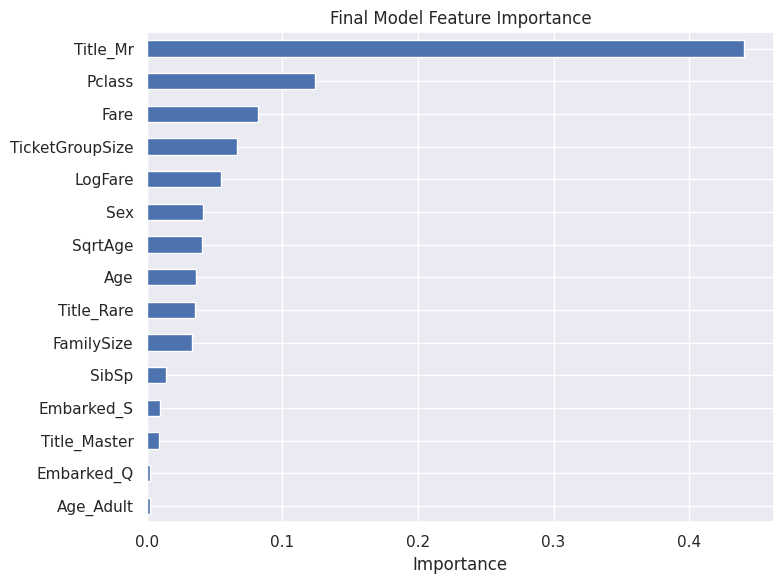

In [392]:
feature_importance = (
    pd.Series(
        final_model.feature_importances_,
        index=X_train.columns,
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

feature_importance.head(15).sort_values().plot.barh()

plt.title("Final Model Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

The feature importance rankings show that the model relies primarily on a relatively small subset of predictors. Variables related to passenger demographics, ticket class, fare, age, and engineered features contribute most strongly to the classification decisions, while the remaining predictors play a comparatively smaller role.

These findings are consistent with the exploratory analysis performed earlier in the project, reinforcing the idea that the feature engineering process successfully captured meaningful information from the original dataset.

### Generate predictions

In [393]:
# Predict test set
y_test_pred = final_model.predict(X_test)

The final model is now trained using all available labeled data, maximizing the information available during training. Its predictions are generated on the unseen test set and will be used to create the Kaggle submission file.

At this stage, the modeling workflow is complete: the remaining step is to format the predictions according to the competition requirements and generate the final submission.


In [394]:
final_model = gradient_boosting


## Kaggle submission

The final step of the workflow is to generate a submission file containing the predictions produced by the selected model on the Kaggle test dataset.

The competition requires predictions to be provided in a specific format, containing the passenger identifier and the predicted survival outcome. The predictions generated by the final classifier are therefore combined with the corresponding `PassengerId` values and exported as a CSV file ready for submission.

### Create the submission file

In [395]:
test_ids = (
    df_full.loc[~df_full["IsTrainSet"], "PassengerId"]
    .reset_index(drop=True)
)

submission = pd.DataFrame(
    {
        "PassengerId": test_ids,
        "Survived": y_test_pred,
    }
)

submission.head()

,PassengerId,Survived
0,892,0.0
1,893,0.0
2,894,0.0
3,895,0.0
4,896,0.0


### Save the submission

In [396]:
submission.to_csv(
    "../data/processed/submission.csv",
    index=False,
)

The generated file follows the format required by the Kaggle Titanic competition and can be submitted to evaluate the model's performance on the hidden test labels.

This completes the end-to-end classification workflow, covering data exploration, feature engineering, model development, evaluation, model comparison, and prediction generation.


## Closing remarks

This project demonstrated a complete end-to-end supervised machine learning workflow using the Kaggle Titanic dataset. Starting from raw data, we explored the dataset, handled missing values, engineered meaningful features, trained and evaluated multiple classification models, compared their performance using both hold-out and cross-validation metrics, and generated a valid Kaggle competition submission.

Although the Titanic competition is often considered an introductory machine learning problem, it provides an excellent opportunity to illustrate many of the fundamental concepts involved in real-world predictive modeling. Throughout the project, emphasis was placed on building a reproducible workflow, understanding each stage of the modeling process, and interpreting the results rather than simply maximizing competition performance.

The techniques presented here—including exploratory data analysis, feature engineering, model evaluation, cross-validation, and model comparison—form the foundation of many practical classification problems encountered in data science. More advanced topics, such as hyperparameter optimization, ensemble methods, probability calibration, and model interpretability, can be built naturally upon this workflow.

I hope this project serves both as a practical introduction for those learning machine learning and as a useful reference for developing future classification models.